# 03 — PatchTST reconstruction on ETTh1

This notebook reconstructs supervised **PatchTST/42** from [*A Time Series Is Worth 64 Words*](https://arxiv.org/abs/2211.14730) using its [official implementation](https://github.com/yuqinie98/PatchTST).

We use exactly the same first task as DLinear: the previous 336 hours of all seven ETTh1 variables are used to forecast the next 96 hours of all seven variables.

## 1. Goals of this notebook

By the end, we will have:

1. connected PatchTST to the Transformer concepts from Lecture 12;
2. inspected how 336 hourly values become 42 patch tokens;
3. verified our implementation against the official GitHub code;
4. trained with chronological validation and no test inspection;
5. compared PatchTST with naive baselines, DLinear and the paper result.

## 2. From the course Transformer to PatchTST

Lecture 12 introduced input projection, positional encoding, multi-head attention, feed-forward layers and residual connections. PatchTST retains those encoder components but changes the meaning of a token.

A standard time-series Transformer may treat each hour as one token. PatchTST groups nearby hours into a patch and treats that local subseries as one token. Attention therefore compares short patterns rather than isolated observations.

PatchTST is also **encoder-only** for this direct forecasting task. Its final linear head converts all encoded patch representations directly into the complete 96-hour forecast.

## 3. Architecture, step by step

For each channel independently:

1. **RevIN:** normalize the 336-hour instance and retain its mean and standard deviation.
2. **Patching:** create overlapping 16-hour patches with stride 8 and replicated end padding.
3. **Patch embedding:** project each 16-value patch into a 16-dimensional token.
4. **Position:** add a learned positional representation so patch order remains known.
5. **Transformer encoder:** process 42 tokens with 3 layers and 4 attention heads.
6. **Forecast head:** flatten the encoded tokens and project directly to 96 future values.
7. **Reverse RevIN:** return the forecast to the input instance's scale.

All seven channels use the same embedding, Transformer and head weights, but each channel creates its own attention maps. No channel can directly read another channel's values.

### 3.1 Official implementation audit

Our focused implementation is in [`src/ts_project/models/patchtst.py`](../src/ts_project/models/patchtst.py). It is adapted with attribution from the Apache-2.0 licensed official supervised implementation at commit `204c21efe0b39603ad6e2ca640ef5896646ab1a9`.

The untouched official model and ours both contain 74 state tensors and 81,728 trainable parameters for this configuration. After loading identical weights and supplying identical inputs, their maximum absolute output difference was exactly **0**.

This proves functional equivalence for the selected PatchTST/42 experiment while allowing our repository to exclude unrelated architectures and options.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader

from ts_project.baselines import last_value_forecast, seasonal_naive_forecast
from ts_project.data import FEATURE_COLUMNS, build_window_datasets, prepare_etth1
from ts_project.metrics import mae, mse, rmse
from ts_project.models import PatchTST
from ts_project.training import seed_everything, train_forecaster

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

with (PROJECT_ROOT / "configs" / "patchtst_reconstruction.yaml").open() as file:
    config = yaml.safe_load(file)

config

{'experiment': {'name': 'patchtst_reconstruction',
  'seed': 2021,
  'source_commit': '204c21efe0b39603ad6e2ca640ef5896646ab1a9'},
 'data': {'dataset': 'ETTh1',
  'input_length': 336,
  'prediction_length': 96,
  'channels': 7,
  'task': 'multivariate_to_multivariate'},
 'patching': {'patch_length': 16,
  'stride': 8,
  'padding': 'end',
  'resulting_patch_count': 42},
 'model': {'name': 'PatchTST',
  'channel_independent': True,
  'encoder_layers': 3,
  'attention_heads': 4,
  'model_dimension': 16,
  'feedforward_dimension': 128,
  'normalization': 'BatchNorm',
  'activation': 'GELU',
  'residual_attention': True,
  'positional_encoding': 'zeros',
  'learnable_positional_encoding': True,
  'revin': True,
  'revin_affine': False,
  'subtract_last': False,
  'decomposition': False,
  'individual_head': False},
 'dropout': {'encoder': 0.3,
  'fully_connected': 0.3,
  'attention': 0.0,
  'head': 0.0},
 'training': {'optimizer': 'Adam',
  'objective': 'MSE',
  'learning_rate': 0.0001,
  '

The YAML file is the resolved experiment recipe. One discrepancy is recorded explicitly: the paper appendix states encoder dropout 0.2, while the official ETTh1 execution script passes 0.3 for encoder and fully-connected dropout. We follow the executable official script.

## 4. Reuse the verified ETTh1 pipeline

Both reconstructions must use the same data. We therefore reuse the tested loader, train-fitted scaler, chronological splits and forecasting windows from the DLinear notebook.

In [2]:
data = prepare_etth1(PROJECT_ROOT / "data" / "raw" / "ETTh1.csv")
input_length = config["data"]["input_length"]
prediction_length = config["data"]["prediction_length"]
seed = config["experiment"]["seed"]

datasets = build_window_datasets(
    data,
    input_length=input_length,
    prediction_length=prediction_length,
)

pd.DataFrame(
    {
        "target rows": [len(data.split(name)) for name in datasets],
        "forecasting windows": [len(dataset) for dataset in datasets.values()],
        "target start": [data.split(name).index.min() for name in datasets],
        "target end": [data.split(name).index.max() for name in datasets],
    },
    index=datasets.keys(),
)

,target rows,forecasting windows,target start,target end
train,8640,8209,2016-07-01,2017-06-25 23:00:00
validation,2880,2785,2017-06-26,2017-10-23 23:00:00
test,2880,2785,2017-10-24,2018-02-20 23:00:00


In [3]:
batch_size = config["training"]["batch_size"]
seed_everything(seed)
train_generator = torch.Generator().manual_seed(seed)

loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=batch_size,
        shuffle=True,
        generator=train_generator,
        num_workers=0,
    ),
    "validation": DataLoader(datasets["validation"], batch_size=batch_size, num_workers=0),
    "test": DataLoader(datasets["test"], batch_size=batch_size, num_workers=0),
}

inputs, targets = next(iter(loaders["train"]))
print("Input batch: ", tuple(inputs.shape))
print("Target batch:", tuple(targets.shape))

Input batch:  (128, 336, 7)
Target batch: (128, 96, 7)


## 5. See the patches before seeing the Transformer

A 16-hour patch and stride 8 mean consecutive patches overlap by 8 hours. The official model replicates eight values at the right boundary, which creates the final patch and yields 42 tokens.

In [4]:
patch_length = config["patching"]["patch_length"]
stride = config["patching"]["stride"]
example_input, _ = datasets["validation"][0]
ot_index = FEATURE_COLUMNS.index("OT")

ot_history = example_input[:, ot_index]
padded_ot = torch.cat([ot_history, ot_history[-1:].expand(stride)])
ot_patches = padded_ot.unfold(0, patch_length, stride)

print("Original OT values:", len(example_input))
print("Patch shape:", tuple(ot_patches.shape), "= [42 patches, 16 hours]")
pd.DataFrame(
    ot_patches[:4].numpy(),
    index=[f"patch {index}" for index in range(4)],
    columns=[f"position {index}" for index in range(patch_length)],
)

Original OT values: 336
Patch shape: (42, 16) = [42 patches, 16 hours]


,position 0,position 1,position 2,position 3,position 4,position 5,position 6,position 7,position 8,position 9,position 10,position 11,position 12,position 13,position 14,position 15
patch 0,-0.195310,-0.226041,-0.310387,-0.356374,-0.318015,-0.272028,-0.264291,-0.295022,-0.256663,-0.256663,-0.264291,-0.195310,-0.164688,-0.187682,-0.149323,-0.157060
patch 1,-0.256663,-0.256663,-0.264291,-0.195310,-0.164688,-0.187682,-0.149323,-0.157060,-0.149323,-0.187682,-0.172317,-0.157060,-0.210676,-0.195310,-0.203047,-0.264291
patch 2,-0.149323,-0.187682,-0.172317,-0.157060,-0.210676,-0.195310,-0.203047,-0.264291,-0.279656,-0.272028,-0.295022,-0.302650,-0.302650,-0.325643,-0.325643,-0.348637
patch 3,-0.279656,-0.272028,-0.295022,-0.302650,-0.302650,-0.325643,-0.325643,-0.348637,-0.341009,-0.325643,-0.409989,-0.348637,-0.379367,-0.310387,-0.287393,-0.279656


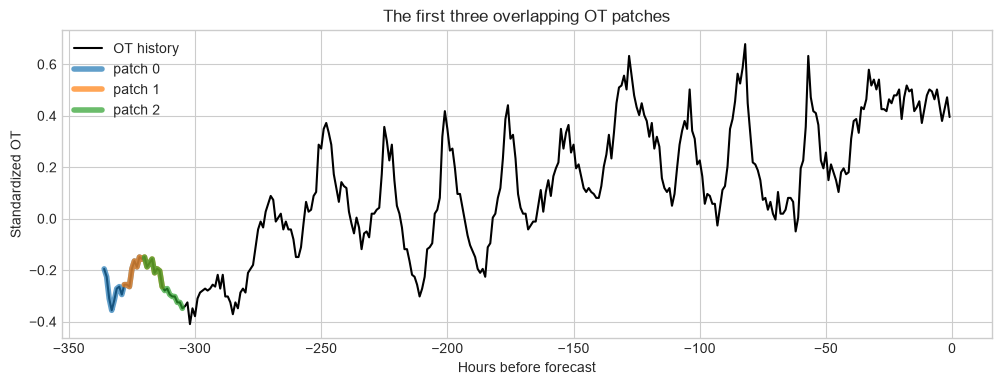

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
hours = range(-input_length, 0)
ax.plot(hours, example_input[:, ot_index], color="black", linewidth=1.5, label="OT history")
colors = ["tab:blue", "tab:orange", "tab:green"]
for patch_index, color in zip(range(3), colors):
    start = patch_index * stride
    ax.plot(
        range(start - input_length, start - input_length + patch_length),
        example_input[start:start + patch_length, ot_index],
        linewidth=4,
        alpha=0.7,
        color=color,
        label=f"patch {patch_index}",
    )
ax.set(title="The first three overlapping OT patches", xlabel="Hours before forecast", ylabel="Standardized OT")
ax.legend()
plt.show()

## 6. Instantiate and inspect PatchTST/42

The model is small by Transformer standards because ETTh1 is a relatively small dataset. The paper deliberately uses 4 heads and a 16-dimensional embedding instead of its larger default architecture to reduce overfitting.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PatchTST(
    input_length=input_length,
    prediction_length=prediction_length,
    channels=config["data"]["channels"],
    patch_length=patch_length,
    stride=stride,
    encoder_layers=config["model"]["encoder_layers"],
    attention_heads=config["model"]["attention_heads"],
    model_dimension=config["model"]["model_dimension"],
    feedforward_dimension=config["model"]["feedforward_dimension"],
    dropout=config["dropout"]["encoder"],
    fully_connected_dropout=config["dropout"]["fully_connected"],
    attention_dropout=config["dropout"]["attention"],
    head_dropout=config["dropout"]["head"],
    revin=config["model"]["revin"],
    revin_affine=config["model"]["revin_affine"],
    subtract_last=config["model"]["subtract_last"],
)

parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print("Device:", device)
print("Patch count:", model.patch_count)
print(f"Trainable parameters: {parameter_count:,}")
print("Forecast shape:", tuple(model(inputs[:2]).shape))

Device: cuda
Patch count: 42
Trainable parameters: 81,728
Forecast shape: (2, 96, 7)


### 6.1 What channel independence means here

The tensor is reshaped so the Transformer sees each channel as a separate series. The same weights learn from HUFL, HULL, MUFL, MULL, LUFL, LULL and OT, but attention for OT only attends to OT patches.

This is why direct cross-channel information remains a possible improvement—but we will not assume it helps. That decision comes only after the faithful reconstruction is complete.

## 7. Train using validation only

The official script uses Adam, MSE, learning rate 0.0001, batch size 128 and up to 100 epochs. Its `type3` schedule holds the initial rate through the early epochs and then decays it gradually by a factor of 0.9.

This is much longer than DLinear. Progress is printed every epoch. Test data is still absent from the training function.

In [7]:
seed_everything(seed)
training_started = time.perf_counter()
training_result = train_forecaster(
    model,
    loaders["train"],
    loaders["validation"],
    device=device,
    learning_rate=config["training"]["learning_rate"],
    learning_rate_schedule=config["training"]["learning_rate_schedule"],
    max_epochs=config["training"]["max_epochs"],
    patience=config["training"]["early_stopping_patience"],
    verbose=True,
)
training_seconds = time.perf_counter() - training_started
history = pd.DataFrame(training_result.history)

print(f"Training time: {training_seconds / 60:.2f} minutes")
print(f"Best epoch: {training_result.best_epoch}")
print(f"Best validation MSE: {training_result.best_validation_mse:.6f}")

Epoch   1/100 | train MSE 0.579952 | validation MSE 0.883743 | lr 1.00e-04


Epoch   2/100 | train MSE 0.453323 | validation MSE 0.760816 | lr 1.00e-04


Epoch   3/100 | train MSE 0.414474 | validation MSE 0.718112 | lr 1.00e-04


Epoch   4/100 | train MSE 0.394882 | validation MSE 0.701548 | lr 1.00e-04


Epoch   5/100 | train MSE 0.383478 | validation MSE 0.694511 | lr 9.00e-05


...

Epoch  96/100 | train MSE 0.355135 | validation MSE 0.677509 | lr 6.17e-09


Epoch  97/100 | train MSE 0.355132 | validation MSE 0.678179 | lr 5.55e-09


Epoch  98/100 | train MSE 0.355277 | validation MSE 0.678057 | lr 5.00e-09


Epoch  99/100 | train MSE 0.355276 | validation MSE 0.677441 | lr 4.50e-09


Epoch 100/100 | train MSE 0.355448 | validation MSE 0.677661 | lr 4.05e-09
Training time: 10.99 minutes
Best epoch: 68
Best validation MSE: 0.677082


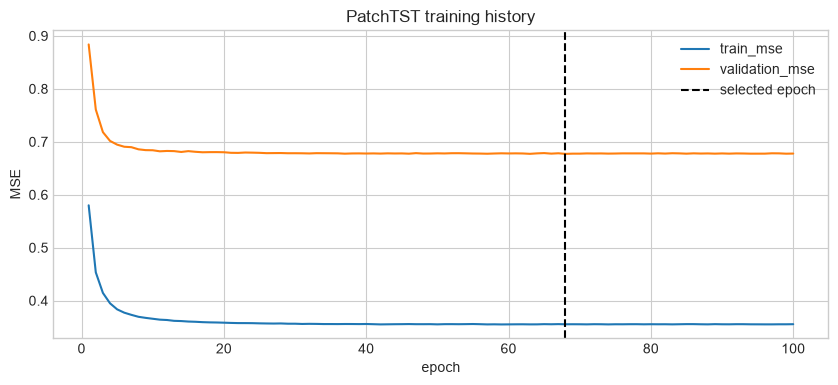

In [8]:
ax = history.plot(
    x="epoch",
    y=["train_mse", "validation_mse"],
    figsize=(10, 4),
)
ax.axvline(training_result.best_epoch, color="black", linestyle="--", label="selected epoch")
ax.set(title="PatchTST training history", ylabel="MSE")
ax.legend()
plt.show()

## 8. Final test comparison

Only after restoring the lowest-validation-MSE checkpoint do we evaluate test. All models are scored on the same complete set of test windows.

In [9]:
def collect_forecasts(loader, forecast_function):
    predictions, actuals = [], []
    for history_batch, target_batch in loader:
        predictions.append(forecast_function(history_batch))
        actuals.append(target_batch)
    return torch.cat(predictions), torch.cat(actuals)


@torch.inference_mode()
def collect_model_forecasts(model, loader, device):
    model.eval()
    predictions, actuals = [], []
    for history_batch, target_batch in loader:
        predictions.append(model(history_batch.to(device)).cpu())
        actuals.append(target_batch)
    return torch.cat(predictions), torch.cat(actuals)


def metric_row(predictions, actuals):
    return {
        "MSE": mse(predictions, actuals).item(),
        "MAE": mae(predictions, actuals).item(),
        "RMSE": rmse(predictions, actuals).item(),
    }

In [10]:
test_last, test_targets = collect_forecasts(
    loaders["test"],
    lambda history_batch: last_value_forecast(history_batch, prediction_length),
)
test_daily, _ = collect_forecasts(
    loaders["test"],
    lambda history_batch: seasonal_naive_forecast(
        history_batch,
        prediction_length,
        season_length=24,
    ),
)
test_patchtst, _ = collect_model_forecasts(model, loaders["test"], device)

test_results = pd.DataFrame(
    {
        "Last value": metric_row(test_last, test_targets),
        "Daily seasonal naive": metric_row(test_daily, test_targets),
        "PatchTST reconstruction": metric_row(test_patchtst, test_targets),
    }
).T
test_results

,MSE,MAE,RMSE
Last value,1.294371,0.713181,1.137704
Daily seasonal naive,0.512225,0.433303,0.715699
PatchTST reconstruction,0.376967,0.398910,0.613976


### 8.1 Compare with the paper and our DLinear run

The paper reports PatchTST/42 MSE 0.375 and MAE 0.399 for this task. These rounded values happen to equal its reported DLinear result at horizon 96. Our comparison uses our own DLinear reconstruction result generated from the same stricter pipeline.

In [11]:
dlinear_metrics_path = (
    PROJECT_ROOT
    / "results"
    / "dlinear"
    / "reconstruction"
    / "etth1"
    / "horizon_096"
    / "seed_2021"
    / "metrics.json"
)
with dlinear_metrics_path.open() as file:
    dlinear_metrics = json.load(file)["DLinear reconstruction"]

comparison = pd.DataFrame(
    {
        "Official PatchTST/42": {"MSE": 0.375, "MAE": 0.399},
        "Our DLinear": dlinear_metrics,
        "Our PatchTST": test_results.loc["PatchTST reconstruction"].to_dict(),
    }
).T[["MSE", "MAE"]]
comparison

,MSE,MAE
Official PatchTST/42,0.375000,0.399000
Our DLinear,0.370509,0.392145
Our PatchTST,0.376967,0.398910


## 9. Per-channel diagnostics

The official aggregate averages every future value and channel. Per-channel metrics are additional diagnostics that may later reveal where an improvement helps or hurts.

In [12]:
per_channel = pd.DataFrame(
    {
        "MSE": [mse(test_patchtst[:, :, i], test_targets[:, :, i]).item() for i in range(len(FEATURE_COLUMNS))],
        "MAE": [mae(test_patchtst[:, :, i], test_targets[:, :, i]).item() for i in range(len(FEATURE_COLUMNS))],
        "RMSE": [rmse(test_patchtst[:, :, i], test_targets[:, :, i]).item() for i in range(len(FEATURE_COLUMNS))],
    },
    index=FEATURE_COLUMNS,
)
per_channel

,MSE,MAE,RMSE
HUFL,0.778541,0.601971,0.882350
HULL,0.210548,0.345043,0.458855
MUFL,0.800373,0.596844,0.894636
MULL,0.171035,0.302127,0.413563
LUFL,0.506752,0.506483,0.711865
LULL,0.118683,0.265879,0.344505
OT,0.052833,0.174025,0.229855


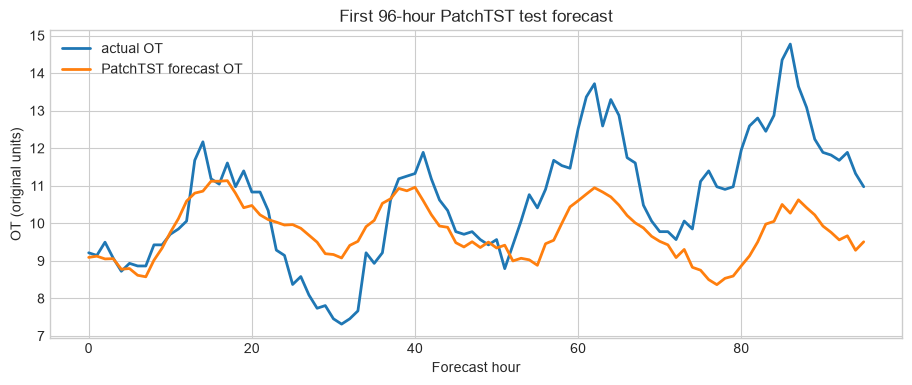

In [13]:
channel_mean = torch.tensor(data.scaler.mean_, dtype=torch.float32)
channel_scale = torch.tensor(data.scaler.scale_, dtype=torch.float32)
actual_original = test_targets[0] * channel_scale + channel_mean
forecast_original = test_patchtst[0] * channel_scale + channel_mean

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(actual_original[:, ot_index], label="actual OT", linewidth=2)
ax.plot(forecast_original[:, ot_index], label="PatchTST forecast OT", linewidth=2)
ax.set(title="First 96-hour PatchTST test forecast", xlabel="Forecast hour", ylabel="OT (original units)")
ax.legend()
plt.show()

## 10. Save compact reproducible artifacts

As with DLinear, we save the resolved configuration, training history, runtime and metrics. We do not save a large checkpoint in Git because the fixed experiment can regenerate it.

In [14]:
result_directory = (
    PROJECT_ROOT
    / "results"
    / "patchtst"
    / "reconstruction"
    / "etth1"
    / f"horizon_{prediction_length:03d}"
    / f"seed_{seed}"
)
result_directory.mkdir(parents=True, exist_ok=True)

with (result_directory / "config.yaml").open("w") as file:
    yaml.safe_dump(config, file, sort_keys=False)
history.to_csv(result_directory / "training_history.csv", index=False)

metrics_to_save = {
    method: {metric: float(value) for metric, value in row.items()}
    for method, row in test_results.to_dict(orient="index").items()
}
metrics_to_save["official_reported_patchtst_42"] = {"MSE": 0.375, "MAE": 0.399}
with (result_directory / "metrics.json").open("w") as file:
    json.dump(metrics_to_save, file, indent=2)
with (result_directory / "runtime.json").open("w") as file:
    json.dump(
        {
            "device": str(device),
            "training_seconds": training_seconds,
            "best_epoch": training_result.best_epoch,
            "parameter_count": parameter_count,
        },
        file,
        indent=2,
    )

print("Saved results to:", result_directory.relative_to(PROJECT_ROOT))

Saved results to: results\patchtst\reconstruction\etth1\horizon_096\seed_2021


## 11. Stop before designing the improvement

This notebook completes the first PatchTST reconstruction experiment. We will now pause and review what DLinear and PatchTST actually learned, where each succeeds, their computational cost, and which improvement ideas have a defensible reason to help.

We will not implement an improvement until its hypothesis, mechanism, comparison and ablation are clear.